In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Flatten,Dense,Conv2D,MaxPooling2D
from tensorflow.keras.optimizers import SGD
from concurrent.futures import ThreadPoolExecutor


In [2]:
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
print("Environment set. TF restricted to 1 thread per instance to allow 12-thread concurrency.")

Environment set. TF restricted to 1 thread per instance to allow 12-thread concurrency.


In [3]:
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()
X_train=X_train.astype(np.float32)/255.0
X_test=X_test.astype(np.float32)/255.0
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [4]:
def iid_partition(x,y,num_clients):
    idx=np.random.permutation(len(x))
    x_shuffled,y_shuffled=x[idx],y[idx]
    x_parts=np.array_split(x_shuffled,num_clients)
    y_parts=np.array_split(y_shuffled,num_clients)
    partitions=list(zip(x_parts,y_parts))
    return partitions

In [5]:
def non_iid_partition(x,y,num_clients):
    sorted_idx=np.argsort(y)
    X_sorted,Y_sorted=x[sorted_idx],y[sorted_idx]
    num_shards=2*num_clients
    size_shards=len(x)//num_shards
    shards_idx=np.random.permutation(num_shards)
    partitions=[]
    for i in range(num_clients):
        s1,s2=shards_idx[2*i],shards_idx[2*i+1]
        X_client=np.concatenate((X_sorted[s1*size_shards:(s1+1)*size_shards],X_sorted[s2*size_shards:(s2+1)*size_shards]),axis=0)
        Y_client=np.concatenate((Y_sorted[s1*size_shards:(s1+1)*size_shards],Y_sorted[s2*size_shards:(s2+1)*size_shards]),axis=0)
        idx = np.random.permutation(len(X_client))
        partitions.append((X_client[idx], Y_client[idx]))
    return partitions


In [6]:
def cnn_model():
    model=Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32,kernel_size=(3,3),activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Conv2D(64,kernel_size=(3,3),activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

In [7]:
def local_training(client_data,global_weights):
    X_local,Y_local=client_data
    num_sample=len(X_local)
    model=cnn_model()
    model.set_weights(global_weights)
    model.fit(X_local,Y_local,epochs=2,batch_size=32,verbose=0)
    local_weights = model.get_weights()
    return local_weights, num_sample
    

In [8]:
class federated_server:
    def __init__(self,X_test,Y_test):
        self.global_model=cnn_model()
        self.X_test=X_test
        self.Y_test=Y_test
    def get_global(self):
        return self.global_model.get_weights()
    def set_global(self,weights):
        self.global_model.set_weights(weights)
    def aggregate_weights(self,client_updates):
        tot_sample=sum(num_samples for _,num_samples in client_updates)
        global_weights=self.get_global()
        new_weights=[np.zeros_like(w) for w in global_weights]
        for local_weights,num_samples in client_updates:
            w_factor=num_samples/tot_sample
            for i in range(len(new_weights)):
                new_weights[i]+=local_weights[i]*w_factor
        self.set_global(new_weights)
    def evaluate_global(self):
        loss, accuracy = self.global_model.evaluate(self.X_test, self.Y_test, verbose=1)
        return loss, accuracy

In [9]:
def run_simulation(partitions, X_test,Y_test,num_clients,rounds):
    server=federated_server(X_test,Y_test)
    max_workers=min(num_clients,12)
    history=[]
    for r in range(1,rounds+1):
        global_weights=server.global_model.get_weights()
        client_updates=[]
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures=[executor.submit(local_training,partitions[i],global_weights) for i in range(num_clients)]
            for future in futures:
                client_updates.append(future.result())
        server.aggregate_weights(client_updates)
        loss,acc=server.evaluate_global()
        history.append({
        'round': r,
        'loss': loss,
        'acc': acc
    })
        print(f"Round {r} | Accuracy: {acc} | Loss: {loss}")
    return history
    

In [10]:
CLIENTS=10
ROUNDS=10
print(f"===RUNNING IID FEDERATED LEARNING ({CLIENTS} Clients)===")
iid_parts=iid_partition(X_train,Y_train,CLIENTS)
iid_history=run_simulation(iid_parts,X_test,Y_test,CLIENTS,ROUNDS)

print(f"===RUNNING NON-IID FEDERATED LEARNING ({CLIENTS} Clients)===")
non_iid_parts=non_iid_partition(X_train,Y_train,CLIENTS)
non_iid_history=run_simulation(non_iid_parts,X_test,Y_test,CLIENTS,ROUNDS)


===RUNNING IID FEDERATED LEARNING (10 Clients)===
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8690 - loss: 0.4494
Round 1 | Accuracy: 0.8690000176429749 | Loss: 0.4493684470653534
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9147 - loss: 0.2881
Round 2 | Accuracy: 0.9146999716758728 | Loss: 0.28806015849113464
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9350 - loss: 0.2273
Round 3 | Accuracy: 0.9350000023841858 | Loss: 0.2272946983575821
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9454 - loss: 0.1868
Round 4 | Accuracy: 0.9453999996185303 | Loss: 0.18679648637771606
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9518 - loss: 0.1604
Round 5 | Accuracy: 0.9517999887466431 | Loss: 0.1603921353816986
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9566 - loss: 0.1439
Round 6 | Accuracy: 0.95660001039505 | Loss: 0.14390142261981964
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9620 - loss: 0.1241
Round 7 | Accuracy: 0

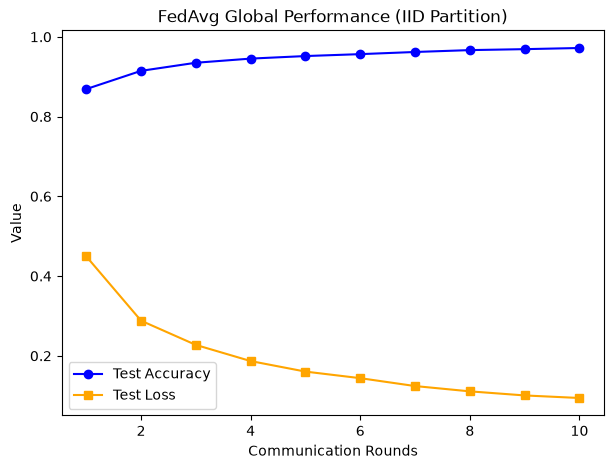

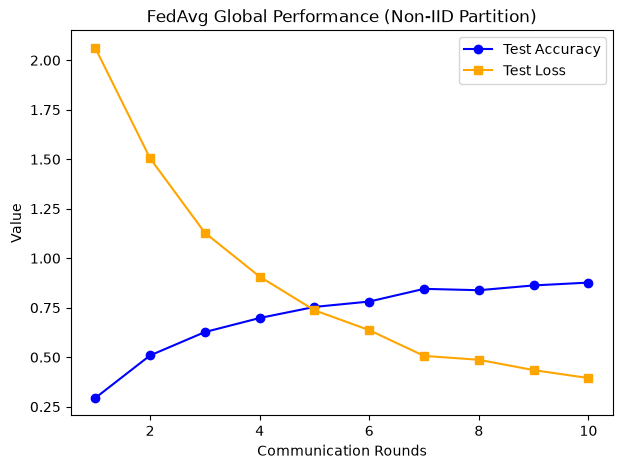

In [11]:
iid_df = pd.DataFrame(iid_history)
non_iid_df = pd.DataFrame(non_iid_history)
# --- IID Plot ---
plt.figure(figsize=(7, 5))
plt.plot(iid_df['round'], iid_df['acc'], marker='o', color='blue', label='Test Accuracy')
plt.plot(iid_df['round'], iid_df['loss'], marker='s', color='orange', label='Test Loss')
plt.title("FedAvg Global Performance (IID Partition)")
plt.xlabel("Communication Rounds")
plt.ylabel("Value")
plt.legend()
plt.show()
# --- Non-IID Plot ---
plt.figure(figsize=(7, 5))
plt.plot(non_iid_df['round'], non_iid_df['acc'], marker='o', color='blue', label='Test Accuracy')
plt.plot(non_iid_df['round'], non_iid_df['loss'], marker='s', color='orange', label='Test Loss')
plt.title("FedAvg Global Performance (Non-IID Partition)")
plt.xlabel("Communication Rounds")
plt.ylabel("Value")
plt.legend()
plt.show()